# Stratified AUC Boxplots

`evaluate_auc.py` output files are used to reproduce `evaluate_delphi.ipynb`-style boxplots for sex-stratified and age-stratified AUC distributions.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = 'figutils/Helvetica.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

# evaluate_auc.py outputs in results/0506 are organized per-dataset subfolder
# with a dataset-specific filename prefix. Switch DATASET below for a single-
# dataset preview, or run the batch cell at the end to regenerate every figure.
RESULTS_BASE = '../results/0506'
DATASET = 'KR'  # one of: KR | KR_full | KR_legacy | JMDC | UKB | UKB_legacy | CKB

# KR and UKB were re-evaluated with --auc_sex_slices all,female,male to
# recover the female/male strata. Those reruns write files with the
# evaluate_auc.py-derived prefix ('val' for kr_val.bin, 'extval_ukb' for
# UKB_extval.bin). The original 0506 KR / UKB folders only contained
# sex='all' and are kept as *_legacy entries for comparison.
DATASET_CFG = {
    'KR':         {'subdir': 'KR_rerun',      'prefix': 'val'},        # rerun w/ sex slices (10k subset)
    'KR_full':    {'subdir': 'KR_rerun_full', 'prefix': 'val'},        # rerun w/ sex slices (all 20559 patients)
    'KR_legacy':  {'subdir': 'KR',            'prefix': 'kr'},         # original 0506 run (no female/male)
    'JMDC':       {'subdir': 'JMDC',          'prefix': 'jmdc'},       # already had sex slices
    'UKB':        {'subdir': 'UKB_rerun',     'prefix': 'extval_ukb'}, # rerun w/ sex slices (10k subset)
    'UKB_legacy': {'subdir': 'UKB',           'prefix': 'ukb'},        # original 0506 run (no female/male)
    'CKB':        {'subdir': 'CKB',           'prefix': 'extval_ckb'},
}
_cfg = DATASET_CFG[DATASET]
RESULTS_DIR = os.path.join(RESULTS_BASE, _cfg['subdir'])
PREFIX = _cfg['prefix']

SEX_CSV = os.path.join(RESULTS_DIR, f'{PREFIX}_df_both_by_sex.csv')
AGE_CSV = os.path.join(RESULTS_DIR, f'{PREFIX}_df_auc_unpooled.csv')

normal_male = '#2166ac'
normal_female = '#b2182b'
age_palette = ['#DCEAF7', '#C3DCF3', '#A4C7EC', '#7FAFDF', '#5C91CF', '#3F73B7', '#2D5A98', '#1E467D']

In [5]:
def _pick_auc_col(df: pd.DataFrame) -> str:
    if 'auc_delong' in df.columns and df['auc_delong'].notna().any():
        return 'auc_delong'
    if 'auc' in df.columns:
        return 'auc'
    raise ValueError('Could not find an AUC column.')


def _build_age_labels(df: pd.DataFrame) -> pd.Series:
    if 'age_bin_years' in df.columns:
        return df['age_bin_years'].astype(str)
    ages = np.sort(df['age'].dropna().unique())
    if len(ages) >= 2:
        step = ages[1] - ages[0]
        return df['age'].map(lambda a: f'[{int(a)}, {int(a + step)})')
    return df['age'].map(lambda a: f'[{int(a)}, ?)')


sex_df = pd.read_csv(SEX_CSV)
sex_auc_col = _pick_auc_col(sex_df)
sex_status_mask = sex_df['status'] == 'ok' if 'status' in sex_df.columns else True
sex_df = sex_df[(sex_df['sex'].isin(['female', 'male'])) & sex_status_mask].copy()
sex_df['auc_value'] = pd.to_numeric(sex_df[sex_auc_col], errors='coerce')
sex_df = sex_df.dropna(subset=['auc_value'])

age_df = pd.read_csv(AGE_CSV)
age_auc_col = _pick_auc_col(age_df)
age_status_mask = age_df['status'] == 'ok' if 'status' in age_df.columns else True
age_df = age_df[(age_df['sex'] == 'all') & age_status_mask].copy()
age_df['auc_value'] = pd.to_numeric(age_df[age_auc_col], errors='coerce')
age_df = age_df.dropna(subset=['auc_value'])
age_df['age_label'] = _build_age_labels(age_df)

print(f'[{DATASET}] sex rows:', len(sex_df), '| tokens:', sex_df['token'].nunique() if len(sex_df) else 0)
print(f'[{DATASET}] age rows:', len(age_df), '| age bins:', age_df['age_label'].nunique())
if len(sex_df) == 0:
    print(f'  (no female/male slices present for {DATASET} — sex boxplot will be empty)')

[KR] sex rows: 0 | tokens: 0
[KR] age rows: 5604 | age bins: 8
  (no female/male slices present for KR — sex boxplot will be empty)


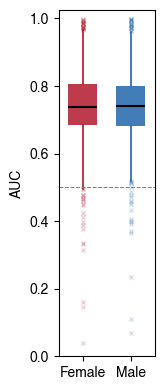

In [3]:
# Sex-stratified AUC boxplot
female_data = sex_df.loc[sex_df['sex'] == 'female', 'auc_value'].values
male_data = sex_df.loc[sex_df['sex'] == 'male', 'auc_value'].values

fig, ax = plt.subplots(figsize=(1.75, 4))

sex_data = [female_data, male_data]
sex_colors = [normal_female, normal_male]
sex_labels = ['Female', 'Male']
positions = [1, 2]

for i in range(2):
    if len(sex_data[i]) == 0:
        continue
    ax.boxplot(
        sex_data[i], positions=[positions[i]], patch_artist=True,
        widths=0.6, whis=[2.5, 97.5], showfliers=True,
        showcaps=False,
        boxprops={'linewidth': 0, 'facecolor': sex_colors[i], 'edgecolor': sex_colors[i], 'alpha':0.85},
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'color': sex_colors[i], 'linewidth': 1.2},
        flierprops={'marker': 'x', 'markerfacecolor': 'none', 'markeredgecolor': sex_colors[i], 'markersize': 3, 'alpha': 0.2},
    )

ax.set_xticks(positions)
ax.set_xticklabels(sex_labels)
ax.set_ylim(0, 1.025)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.75)
ax.set_axisbelow(True)
ax.set_ylabel('AUC')
plt.tight_layout()
plt.grid(axis='x', visible=False)
plt.savefig(f'auc_sex_stratified_{DATASET}.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Age-stratified AUC boxplot (all sexes pooled)
age_order = sorted(age_df['age'].unique())

def _age_tick(a):
    nxt = a + 5
    return f'{int(a)}-{int(nxt - 1)}'

age_labels = [_age_tick(a) for a in age_order]
age_data = [age_df.loc[age_df['age'] == a, 'auc_value'].values for a in age_order]
positions = np.arange(1, len(age_order) + 1)

fig_width = max(5.5, 0.3 * len(age_order))
fig, ax = plt.subplots(figsize=(fig_width, 4))

for i, values in enumerate(age_data):
    color = age_palette[i % len(age_palette)]
    if len(values) == 0:
        continue
    ax.boxplot(
        values, positions=[positions[i]], patch_artist=True,
        widths=0.5, whis=[2.5, 97.5], showfliers=True,
        showcaps=False,
        boxprops={'linewidth': 1.15, 'facecolor': color, 'edgecolor': color},
        medianprops={'color': 'black', 'linewidth': 1.4},
        whiskerprops={'color': color, 'linewidth': 1.2},
        flierprops={'marker': 'x', 'markerfacecolor': 'none', 'markeredgecolor': color, 'markersize': 2.5, 'alpha': 0.25},
    )

ax.set_xticks(positions)
ax.set_xticklabels(age_labels, ha='center', fontsize=10)
ax.set_ylim(0, 1.025)
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.75)
ax.set_axisbelow(True)
ax.set_ylabel('AUC')
ax.set_xlabel('Prediction-time age group (years)', fontsize=10)
plt.tight_layout()
plt.grid(axis='x', visible=False)
plt.savefig(f'auc_age_stratified_{DATASET}.pdf', bbox_inches='tight')
plt.show()

## Batch: KR / JMDC / UKB all stratifications

The cells above are convenient for a single-dataset preview. The next cell regenerates **all six PDFs** in one shot: sex-stratified and age-stratified boxplots for KR, JMDC, and UKB (using the rerun folders that contain female/male slices).

In [ ]:
# Batch generator: KR / JMDC / UKB × {sex-stratified, age-stratified}
# Saves 6 PDFs alongside this notebook.

def _load_dataset(name):
    """Load and filter sex_df / age_df for one dataset key from DATASET_CFG."""
    cfg = DATASET_CFG[name]
    rdir = os.path.join(RESULTS_BASE, cfg['subdir'])
    pfx = cfg['prefix']
    sex_csv = os.path.join(rdir, f'{pfx}_df_both_by_sex.csv')
    age_csv = os.path.join(rdir, f'{pfx}_df_auc_unpooled.csv')

    sdf = pd.read_csv(sex_csv)
    s_auc_col = _pick_auc_col(sdf)
    s_mask = sdf['status'] == 'ok' if 'status' in sdf.columns else True
    sdf = sdf[(sdf['sex'].isin(['female', 'male'])) & s_mask].copy()
    sdf['auc_value'] = pd.to_numeric(sdf[s_auc_col], errors='coerce')
    sdf = sdf.dropna(subset=['auc_value'])

    adf = pd.read_csv(age_csv)
    a_auc_col = _pick_auc_col(adf)
    a_mask = adf['status'] == 'ok' if 'status' in adf.columns else True
    adf = adf[(adf['sex'] == 'all') & a_mask].copy()
    adf['auc_value'] = pd.to_numeric(adf[a_auc_col], errors='coerce')
    adf = adf.dropna(subset=['auc_value'])
    adf['age_label'] = _build_age_labels(adf)
    return sdf, adf


def _plot_sex(sdf, name, save_path):
    female_data = sdf.loc[sdf['sex'] == 'female', 'auc_value'].values
    male_data = sdf.loc[sdf['sex'] == 'male', 'auc_value'].values
    fig, ax = plt.subplots(figsize=(1.75, 4))
    data, colors, labels, positions = (
        [female_data, male_data], [normal_female, normal_male], ['Female', 'Male'], [1, 2]
    )
    for i in range(2):
        if len(data[i]) == 0:
            continue
        ax.boxplot(
            data[i], positions=[positions[i]], patch_artist=True,
            widths=0.6, whis=[2.5, 97.5], showfliers=True, showcaps=False,
            boxprops={'linewidth': 0, 'facecolor': colors[i], 'edgecolor': colors[i], 'alpha': 0.85},
            medianprops={'color': 'black', 'linewidth': 1.5},
            whiskerprops={'color': colors[i], 'linewidth': 1.2},
            flierprops={'marker': 'x', 'markerfacecolor': 'none', 'markeredgecolor': colors[i],
                        'markersize': 3, 'alpha': 0.2},
        )
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.025)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.75)
    ax.set_axisbelow(True)
    ax.set_ylabel('AUC')
    ax.set_title(name, y=1.03, fontsize=10)
    plt.tight_layout()
    plt.grid(axis='x', visible=False)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def _plot_age(adf, name, save_path):
    age_order = sorted(adf['age'].unique())
    age_labels_ = [f'{int(a)}-{int(a + 4)}' for a in age_order]
    age_data = [adf.loc[adf['age'] == a, 'auc_value'].values for a in age_order]
    positions = np.arange(1, len(age_order) + 1)
    fig_width = max(5.5, 0.3 * len(age_order))
    fig, ax = plt.subplots(figsize=(fig_width, 4))
    for i, values in enumerate(age_data):
        if len(values) == 0:
            continue
        color = age_palette[i % len(age_palette)]
        ax.boxplot(
            values, positions=[positions[i]], patch_artist=True,
            widths=0.5, whis=[2.5, 97.5], showfliers=True, showcaps=False,
            boxprops={'linewidth': 1.15, 'facecolor': color, 'edgecolor': color},
            medianprops={'color': 'black', 'linewidth': 1.4},
            whiskerprops={'color': color, 'linewidth': 1.2},
            flierprops={'marker': 'x', 'markerfacecolor': 'none', 'markeredgecolor': color,
                        'markersize': 2.5, 'alpha': 0.25},
        )
    ax.set_xticks(positions)
    ax.set_xticklabels(age_labels_, ha='center', fontsize=10)
    ax.set_ylim(0, 1.025)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.75)
    ax.set_axisbelow(True)
    ax.set_ylabel('AUC')
    ax.set_xlabel('Prediction-time age group (years)', fontsize=10)
    ax.set_title(name, y=1.03, fontsize=10)
    plt.tight_layout()
    plt.grid(axis='x', visible=False)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


BATCH_DATASETS = ['KR', 'JMDC', 'UKB']
batch_summary = []
for name in BATCH_DATASETS:
    sdf_, adf_ = _load_dataset(name)
    print(f'[{name}] sex rows={len(sdf_)} (tokens={sdf_["token"].nunique() if len(sdf_) else 0}) | '
          f'age rows={len(adf_)} bins={adf_["age_label"].nunique()}')
    _plot_sex(sdf_, name, f'auc_sex_stratified_{name}.pdf')
    _plot_age(adf_, name, f'auc_age_stratified_{name}.pdf')
    batch_summary.append({
        'dataset': name,
        'sex_rows': len(sdf_),
        'sex_tokens': int(sdf_['token'].nunique()) if len(sdf_) else 0,
        'age_rows': len(adf_),
        'age_bins': int(adf_['age_label'].nunique()),
    })

pd.DataFrame(batch_summary).set_index('dataset')